Dudas de la implementación:

- ¿Medimos cada dt n_vnodes veces o dt_virtual = dt/n_vndes?
- Para hacer las secuencias, ¿Habria que hacer un minmax distinto para cada valor de t para evitar fuga de datos o vale con crear las features una única vez y hacer las secuencias?
- La capa lineal final, ¿con o sin bias?
- ¿El preprocesado de datos es correcto?

In [1]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 18.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import qutip as qt

from google.colab import files

In [5]:
uploaded = files.upload()

Saving data.csv to data.csv


# Fully-Conected Quantum Ising Model

The Quantum Reservoir (QR) is based on a fully-connected transverse-field Ising model. The protocol starts with the initialization in the pure product state:

$$
\rho_0 = |+\rangle^{\otimes N} \langle +|^{\otimes N}.
$$

Then, a normalized scalar input $x_l\in [0,1]$ is encoded into the quantum reservoir by updating the density matrix as it follows:

$$
\rho \mapsto |\psi(x_l)\rangle \langle \psi(x_l)| \otimes \text{Tr}_0[\rho],
$$

where:

$$
|\psi(x_l)\rangle = \sqrt{1-x_l}|0\rangle + \sqrt{x_l}|1\rangle.
$$

This way, at each step, the first qubit is overwriten with a stated that contains information about the new input throught amplitude encoding.

Thereafter, the system evolves under the time-independent Hamiltonian:

$$
H=\sum_{i<j}J_{i,j} X_i X_j + \sum_i h_i Z_i,
$$

where $X_i$ and $Z_i$ are Pauli operators acting on qubit $i$, $J_{i,j}$ represents inter-qubit couplings and $h_i$ represents local transverse magnetic fields.

The state evolves thougth $V$ uniformly spaced time intervals (virtual nodes), during which the observables

$$
\langle Z_i(t_k) \rangle = \text(Tr)[Z_i \rho(t_k)]
$$

are measured. The resulting set of measurements form a feature vector of dimension $V\times n_{qubits}$ for each input $x_l$. After processing a full window, the linear readout weights are trained using the Moore-Penrose pseudoinverse solution to minimize the MSE between predictions and targets. The final layer can be expressed as:

$$
\hat{Y} = XW,
$$

where $X$ contains the features of the reservoir, $W$ contains the optimizable weigths and $\hat{Y}$ contains the predictions.

Number of days in the dataset: 1259


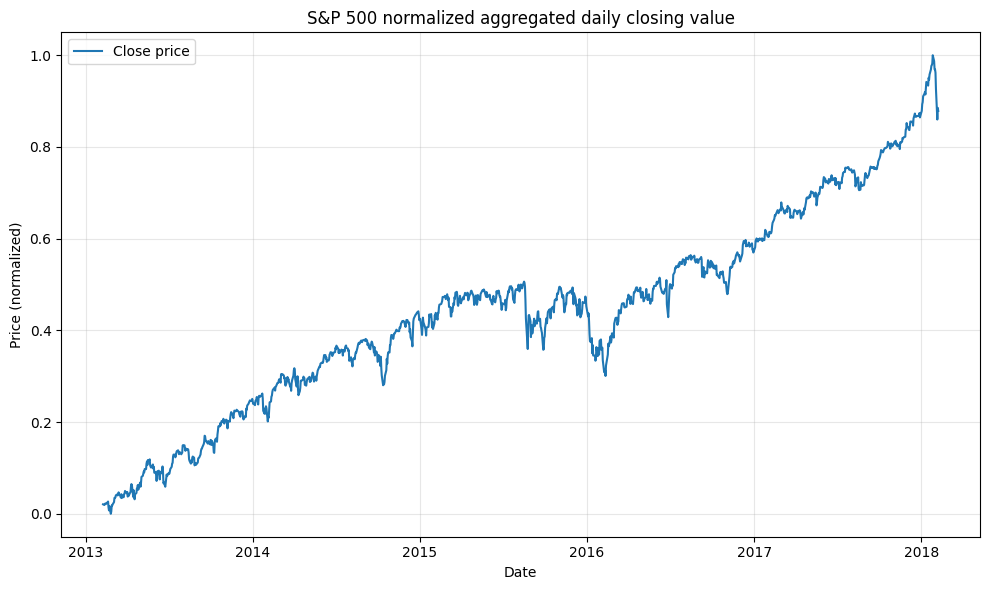

In [96]:
# ===========================================================================
# IMPORT DATA AND CREATE THE NORMALIZED AGGREGATED DAILY CLOSING TIME SERIE
# ===========================================================================

# Read csv
df = pd.read_csv("data.csv")

# Aggregate closing price
df["date"] = pd.to_datetime(df["date"])
df = df.groupby("date").agg(
    close=("close", "sum"),
)

# Normalize
min_price = df["close"].min()
max_price = df["close"].max()
df["close"] = (df["close"] - min_price) / (max_price - min_price)

# Get the number of rows
n_days = df.shape[0]
print("Number of days in the dataset:", n_days)

# Plot the time serie
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df.index, df["close"], label="Close price")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("S&P 500 normalized aggregated daily closing value")
ax.set_ylabel("Price (normalized)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [108]:
# ===============================================================
# DEFINE DATA AND QUANTUM OBJECTS
# ===============================================================

# Data and parameters
n_seeds = 200
data = df["close"]
data = np.asarray(data, dtype=np.float64).reshape(-1)
window_size = 4
horizon_size = 25

couplings = 0.5
n_qubits = 6
n_vnodes = 2
dt = 0.3

# Not sure which one the paper uses
virtual_dt = dt / n_vnodes
virtual_dt = dt


# Quantum objects n = 1
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)
ket_plus = (ket0 + ket1).unit()

# Initial pure state (n = nqubits)
initial_ket = qt.tensor(
    [ket_plus for _ in range(n_qubits)]
)
initial_rho = qt.ket2dm(initial_ket)

def local_operator(
    operator: qt.Qobj,
    qubit: int,
    n_qubits: int
) -> qt.Qobj:
  """
  Builds the operator I ⊗ ... ⊗ operator ⊗ ... ⊗ I
  With operator in the position "qubit"
  """
  operators = [qt.qeye(2) for _ in range(n_qubits)]
  operators[qubit] = operator

  return qt.tensor(operators)

# Build the Hamiltonian
X_list = [
    local_operator(qt.sigmax(), i, n_qubits)
    for i in range(n_qubits)
]

Z_list = [
    local_operator(qt.sigmaz(), i, n_qubits)
    for i in range(n_qubits)
]

U_list = []

for seed in range(n_seeds):
  rng = np.random.default_rng(seed)

  local_fields = rng.uniform(
      low=0.1,
      high=1.0,
      size=n_qubits
  )

  H = 0 * Z_list[0]

  for j in range(n_qubits):
    for i in range(j):
      H += couplings * X_list[i] * X_list[j]

  for i in range(n_qubits):
    H += local_fields[i] * Z_list[i]

  # Evolution operator
  U = (-1j * H * virtual_dt).expm()

  U_list.append(U)

In [109]:
# ===============================================================
# GET THE FEATURES FROM THE RESERVOIR
# ===============================================================

reservoir_features_list = []

for U in U_list:
  U_dag = U.dag()
  rho = initial_rho.copy()
  reservoir_features = []

  for xl in data[:1200]:
    # Amplitude encoding
    psi_xl = np.sqrt(1-xl) * ket0 + np.sqrt(xl) * ket1

    # Partial trace
    rho_rest = rho.ptrace(list(range(1, n_qubits)))

    # Updated state
    rho = qt.tensor(
        qt.ket2dm(psi_xl),
        rho_rest
    )

    features_xl = []

    # Evolve state and measure for each virtual node
    for node in range(n_vnodes):
      rho = U * rho * U_dag  # Evolve with virtual_dt timestep

      # "n_qubits" measurements
      measurements = [
          qt.expect(Z_i, rho)
          for Z_i in Z_list
      ]

      # "n_qubits * n_vnodes" features
      features_xl.extend(measurements)

    # "(t+1, n_qubits * n_vnodes)" features
    reservoir_features.append(features_xl)

  reservoir_features = np.asarray(
    reservoir_features,
    dtype=np.float64
  )

  reservoir_features_list.append(reservoir_features)

print(np.array(reservoir_features_list).shape)

(200, 1200, 12)


In [110]:
# ===============================================================
# DEFINE A FUNCTION TO CREATE THE TRAINING SEQUENCES
# ===============================================================

def create_training_sequences(
    window_data: np.ndarray,
    horizon_data: np.ndarray,
    train_end: int,
    window_size: int,
    horizon_size: int
) -> tuple[np.ndarray, np.ndarray]:
  """
  Creates the training sequences for the linear readout.
  """
  X_train = []
  y_train = []

  for i in range(train_end - window_size -  horizon_size + 2):
    X_train.append(window_data[i : i + window_size].reshape(-1))
    y_train.append(horizon_data[i + window_size: i + window_size + horizon_size])

  return np.array(X_train), np.array(y_train)

In [111]:
# ===============================================================
# GET THE PREDICTIONS AND RESULTS (WITH BIAS)
# ===============================================================

results_seed = []

for reservoir_features in reservoir_features_list:
  results_t = {}

  for t in range(1100, 1200):

    # Create the feature sequences
    X_train, y_train = create_training_sequences(
        window_data=reservoir_features,
        horizon_data=data,
        train_end=t,
        window_size=window_size,
        horizon_size=horizon_size
    )

    # X_train.shape == (n_samples, 48)
    # y_train.shape == (n_samples, 25)

    X_train_bias = np.column_stack([
      np.ones(len(X_train)),
      X_train
    ])

    # Pseudoinverse
    X_pinv = np.linalg.pinv(X_train_bias) # (48, n_samples)
    W = X_pinv @ y_train # (48, 25)

    # Get the predictions
    X_test = reservoir_features[t - window_size + 1:t + 1] # (4, 12)
    X_test = X_test.reshape(1, -1) # (1, 48)

    X_test_bias = np.column_stack([
      np.ones(len(X_test)),
      X_test
    ])

    y_test = data[t + 1:t + horizon_size + 1].reshape(1, -1)

    y_pred = X_test_bias @ W # (1, 25)

    mae  = np.abs(y_pred - y_test).reshape(-1)
    mae_t = mae.mean()

    # Save the results
    results_t[t] = {
        "y_pred": y_pred,
        "y_test": y_test,
        "mae": mae,
        "mae_t": mae_t
    }

  results_seed.append(results_t)

In [ ]:
# ===============================================================
# GET THE PREDICTIONS AND RESULTS (WITHOUT BIAS)
# ===============================================================

results_seed = []

for reservoir_features in reservoir_features_list:
  results_t = {}

  for t in range(1100, 1200):

    # Create the feature sequences
    X_train, y_train = create_training_sequences(
        window_data=reservoir_features,
        horizon_data=data,
        train_end=t,
        window_size=window_size,
        horizon_size=horizon_size
    )

    # X_train.shape == (n_samples, 48)
    # y_train.shape == (n_samples, 25)

    # Pseudoinverse
    X_pinv = np.linalg.pinv(X_train) # (48, n_samples)
    W = X_pinv @ y_train # (48, 25)

    # Get the predictions
    X_test = reservoir_features[t - window_size + 1:t + 1] # (4, 12)
    X_test = X_test.reshape(1, -1) # (1, 48)

    y_test = data[t + 1:t + horizon_size + 1].reshape(1, -1)

    y_pred = X_test @ W # (1, 25)

    mae  = np.abs(y_pred - y_test).reshape(-1)
    mae_t = mae.mean()

    # Save the results
    results_t[t] = {
        "y_pred": y_pred,
        "y_test": y_test,
        "mae": mae,
        "mae_t": mae_t
    }

  results_seed.append(results_t)

In [112]:
# ===============================================================
# BASELINE LINEAL READOUT MODEL (WITH BIAS)
# ===============================================================

results_baseline = {}

for t in range(1100, 1200):

  # Create the baseline sequences
  X_train_base, y_train_base = create_training_sequences(
      window_data=data,
      horizon_data=data,
      train_end=t,
      window_size=window_size,
      horizon_size=horizon_size
  )

  X_train_base_bias = np.column_stack([
    np.ones(len(X_train_base)),
    X_train_base
  ])

  # Pseudoinverse
  X_pinv_base = np.linalg.pinv(X_train_base_bias) # (5, n_samples)
  W_base = X_pinv_base @ y_train_base # (5, 25)

  # Get the predictions
  X_test_base = data[t - window_size + 1:t + 1].reshape(1, -1) # (1, 4)

  X_test_bias_base = np.column_stack([
    np.ones(len(X_test_base)),
    X_test_base
  ]) # (1, 5)

  y_test_base = data[t + 1:t + horizon_size + 1].reshape(1, -1) # (1, 25)

  y_pred_base = X_test_bias_base @ W_base # (1, 25)

  mae_base  = np.abs(y_pred_base - y_test_base).reshape(-1) # (25,)
  mae_t_base = mae_base.mean() # ()

  # Save the results
  results_baseline[t] = {
      "y_pred": y_pred_base,
      "y_test": y_test_base,
      "mae": mae_base,
      "mae_t": mae_t_base
  }


In [113]:
# ===============================================================
# BASELINE LINEAL READOUT MODEL (WITHOUT BIAS)
# ===============================================================

results_baseline_unbiased = {}

for t in range(1100, 1200):

  # Create the baseline sequences
  X_train_base, y_train_base = create_training_sequences(
      window_data=data,
      horizon_data=data,
      train_end=t,
      window_size=window_size,
      horizon_size=horizon_size
  )

  # Pseudoinverse
  X_pinv_base = np.linalg.pinv(X_train_base) # (4, n_samples)
  W_base = X_pinv_base @ y_train_base # (4, 25)

  # Get the predictions
  X_test_base = data[t - window_size + 1:t + 1].reshape(1, -1) # (1, 4)


  y_test_base = data[t + 1:t + horizon_size + 1].reshape(1, -1) # (1, 25)

  y_pred_base = X_test_base @ W_base # (1, 25)

  mae_base  = np.abs(y_pred_base - y_test_base).reshape(-1) # (25,)
  mae_t_base = mae_base.mean() # ()

  # Save the results
  results_baseline_unbiased[t] = {
      "y_pred": y_pred_base,
      "y_test": y_test_base,
      "mae": mae_base,
      "mae_t": mae_t_base
  }


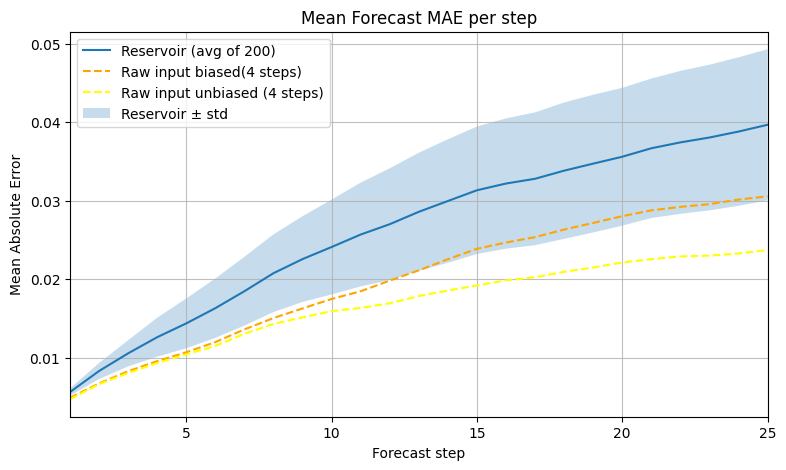

In [114]:
# ===============================================================
# PLOT THE RESULTS
# ===============================================================

# Get the values
mae_values = np.array([
    [
        np.asarray(result_t["mae"])
        for result_t in results_t.values()
    ]
    for results_t in results_seed
]) # (50, 100, 25)

mae_values_base = np.array([
    results["mae"]
    for results in results_baseline.values()
]) # (100, 25)

mae_values_base_unbiased = np.array([
    results["mae"]
    for results in results_baseline_unbiased.values()
]) # (100, 25)

# Average and std through the timestep
mean_mae_per_step_base = mae_values_base.mean(axis=0)
mean_mae_per_step_base_unbiased = mae_values_base_unbiased.mean(axis=0)

mae_per_seed = mae_values.mean(axis=1)

mean_mae_per_step = mae_per_seed.mean(axis=0)
std_mae_per_step = mae_per_seed.std(axis=0, ddof=1)

lower_bound = mean_mae_per_step - std_mae_per_step
upper_bound = mean_mae_per_step + std_mae_per_step

# Plot results
forecast_steps = np.arange(1, horizon_size + 1)
plt.figure(figsize=((9, 5)))
plt.plot(
    forecast_steps,
    mean_mae_per_step,
    label=f"Reservoir (avg of {n_seeds})"
)
plt.plot(
    forecast_steps,
    mean_mae_per_step_base,
    linestyle="--",
    color="orange",
    label=f"Raw input biased({window_size} steps)"
)

plt.plot(
    forecast_steps,
    mean_mae_per_step_base_unbiased,
    linestyle="--",
    color="yellow",
    label=f"Raw input unbiased ({window_size} steps)"
)

plt.fill_between(
    forecast_steps,
    lower_bound,
    upper_bound,
    alpha=0.25,
    label="Reservoir ± std"
)
plt.title("Mean Forecast MAE per step")
plt.xlabel("Forecast step")
plt.ylabel("Mean Absolute Error")
plt.xlim(1, 25)
plt.grid(alpha=0.8)
plt.legend()
plt.show()